# Quantitative Textanalyse

In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import Counter, defaultdict
from scipy.stats import spearmanr, linregress
from nltk.corpus import stopwords
import re

In [2]:
df = pd.read_csv("../data/wikipedia_text.csv", sep = ",")

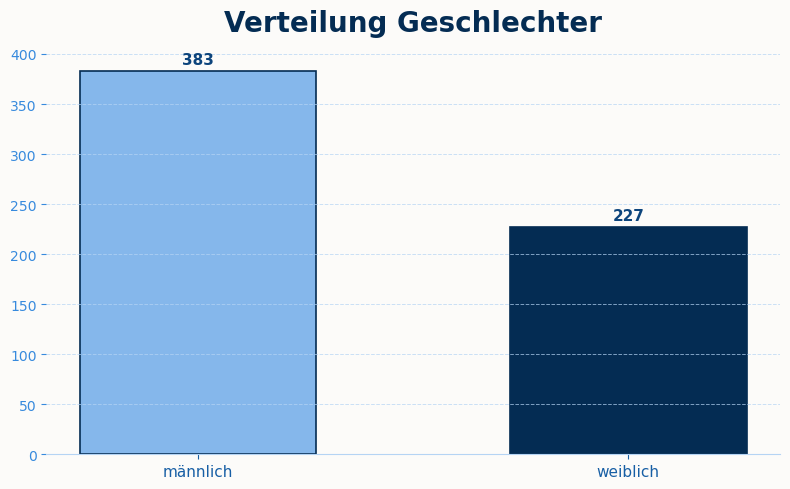

In [3]:
counts = df.groupby("genderLabel").size()

fig, ax = plt.subplots(figsize=(8, 5))

blues = ["#85B7EB", "#042C53"]
colors = [blues[i % len(blues)] for i in range(len(counts))]

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="#042C53",
              linewidth=1.2, width=0.55)

# Count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + counts.values.max() * 0.01,
            f"{int(height):,}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="#0C447C")

# Styling
ax.set_facecolor("#fcfbf9")
fig.patch.set_facecolor("#fcfbf9")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#B5D4F4")
ax.tick_params(axis="x", colors="#185FA5", labelsize=11)
ax.tick_params(axis="y", colors="#378ADD", labelsize=10)
ax.grid(axis="y", color="#B5D4F4", linestyle="--", linewidth=0.7, alpha=0.7)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Verteilung Geschlechter", fontsize=20, fontweight="bold",
             color="#042C53", pad=15)
plt.tight_layout()
plt.savefig("../figures/verteilung_geschlechter.png", dpi=300)
plt.show()

# Stopwörter und Tokenisierung
Die Stoppwörter werden nach der Standardliste von NLTK für Deutsch und Englisch erweitert um häufige, aber wenig informative Wörter aus Wikipedia-Texten (z.B. "abgerufen", "online", "doi").
 Die Tokenisierung erfolgt durch eine einfache Regex, die nur alphabetische Zeichen und deutsche Umlaute berücksichtigt. Wörter, die mit einem Großbuchstaben beginnen (vermutlich Substantive) werden ignoriert, um den Fokus auf Verben, Adjektive und andere Wortarten zu legen, die möglicherweise geschlechtsspezifische Assoziationen aufweisen.

In [4]:
STOPWORDS = set(stopwords.words("german")) | set(stopwords.words("english"))

STOPWORDS.update({"https", "http", "www", "org", "abgerufen", "online",
                  "doi", "isbn", "hrsg", "einzelnachweise", "seite", "band", "beim", "drei",
                  "mehr", "seit", "deren", "heute"})

STOPWORDS.update({"deutsche", "deutscher", "deutsches", "deutschen",
                  "amerikanische", "amerikanischer",
                  "englische", "englisch",
                  "britische", "britischer",
                  "französische", "französischer",
                  "österreichische", "österreichischer",
                  "schweizerische", "schweizerischer",
                  "russisch"})

In [5]:
def tokenize(text: str) -> list:
    text = re.sub(r"={1,6}[^=]+={1,6}", "", text) #Überschriften entfernen
    tokens = []
    for w in re.findall(r"[a-zA-ZäöüÄÖÜß]+", text):
        if w[0].isupper():
            continue
        w = w.lower()
        if w not in STOPWORDS and len(w) > 2:
            tokens.append(w)
    return tokens

In [6]:
def collect_corpora(df):
    corpora = {"männlich": [], "weiblich": []}
    for _, row in df.iterrows():
        gender = row["genderLabel"].strip().lower()
        if gender in corpora:
            tokens = tokenize(row["text"])
            corpora[gender].extend(tokens)
    return corpora

## Häufigkeitsanalyse und Rang-Korrelation

In [7]:
def word_frequencies(tokens: list) -> dict:
    counts = Counter(tokens)
    total = sum(counts.values())
    return {w: c / total for w, c in counts.items()}

In [8]:
def rank_correlation(freq_m: dict, freq_f: dict):
    """Spearman rank correlation on shared vocabulary."""
    common = set(freq_m) & set(freq_f)
    if len(common) < 10:
        return None, None, 0
    words = list(common)
    fm = [freq_m[w] for w in words]
    ff = [freq_f[w] for w in words]
    rho, pval = spearmanr(fm, ff)
    return rho, pval, len(common)

## PMI (Pointwise Mutual Information): Wortassoziationen pro Gruppe

In [9]:
def compute_pmi(corpora: dict, top_n: int = 30) -> dict:
    """
    PMI(word, gender) = log[ P(word, gender) / (P(word) * P(gender)) ]
    Positive PMI = word is more associated with that gender.
    """
    all_tokens = corpora["männlich"] + corpora["weiblich"]
    total = len(all_tokens)
    n_male = len(corpora["männlich"])
    n_female = len(corpora["weiblich"])

    p_gender = {"männlich": n_male / total, "weiblich": n_female / total}

    all_counts = Counter(all_tokens)
    gender_counts = {g: Counter(corpora[g]) for g in ("männlich", "weiblich")}

    pmi = defaultdict(dict)
    for word, global_count in all_counts.items():
        if global_count < 60:
            continue
        p_word = global_count / total
        for gender in ("männlich", "weiblich"):
            gc = gender_counts[gender].get(word, 0)
            p_word_gender = gc / total
            if p_word_gender == 0:
                pmi[gender][word] = -np.inf
            else:
                pmi[gender][word] = math.log2(p_word_gender / (p_word * p_gender[gender]))

    top_male   = sorted(pmi["männlich"],   key=lambda w: pmi["männlich"][w],   reverse=True)[:top_n]
    top_female = sorted(pmi["weiblich"], key=lambda w: pmi["weiblich"][w], reverse=True)[:top_n]
    return {"männlich": {w: pmi["männlich"][w]   for w in top_male},
            "weiblich": {w: pmi["weiblich"][w] for w in top_female},
            "all": pmi}

# Visualisierungen

In [24]:
COLORS = {"male": "#85B7EB", "female": "#042C53"}

def plot_pmi(pmi_data: dict, top_n: int = 20):
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    fig.patch.set_facecolor("#fcfbf9")

    colors = {"männlich": "#85B7EB", "weiblich": "#042C53"}

    for ax, gender in zip(axes, ("männlich", "weiblich")):
        words = list(pmi_data[gender].keys())[:top_n]
        scores = [pmi_data[gender][w] for w in words]
        y_pos = np.arange(len(words))

        ax.barh(y_pos, scores, color=colors[gender], alpha=0.85, height=0.6)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=10, color="#0C447C")
        ax.invert_yaxis()

        ax.set_facecolor("#fcfbf9")
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["bottom", "left"]].set_color("#B5D4F4")
        ax.tick_params(axis="x", colors="#378ADD", labelsize=9)
        ax.tick_params(axis="y", colors="#0C447C", labelsize=12)
        ax.grid(axis="x", color="#B5D4F4", linestyle="--", linewidth=0.6, alpha=0.7)
        ax.set_xlabel("PMI (Bits)")
        ax.set_title(f"Top-Wörter assoziiert mit {'männlichen' if gender == 'männlich' else 'weiblichen'} Wissenschaftler:innen")
        ax.axvline(0, color="#185FA5", linewidth=0.9, linestyle="-")
    x_min = min(ax.get_xlim()[0] for ax in axes)
    x_max = max(ax.get_xlim()[1] for ax in axes)
    for ax in axes:
        ax.set_xlim(x_min, x_max)

    plt.suptitle("Wortassoziationen nach Geschlecht (PMI)",
             fontsize=20, fontweight="bold", color="#042C53", y=1.01)
    plt.tight_layout()
    plt.savefig("../figures/wort_assoziazionen.png", bbox_inches="tight", dpi=300)
    plt.show()

def plot_rank_scatter(freq_m: dict, freq_f: dict):
    common = set(freq_m) & set(freq_f)
    words = list(common)
    fm = np.array([freq_m[w] for w in words])
    ff = np.array([freq_f[w] for w in words])

    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor("#fcfbf9")
    ax.set_facecolor("#fcfbf9")

    ax.scatter(np.log10(fm), np.log10(ff), alpha=0.25, s=6, color="#85B7EB")

    # Interessanteste Wörter annotieren
    interesting = sorted(common, key=lambda w: abs(freq_m[w] - freq_f[w]),
                         reverse=True)[:12]
    for w in interesting:
        ax.annotate(w, (np.log10(freq_m[w]), np.log10(freq_f[w])),
                    fontsize=10, color="#042C53", alpha=0.9,
                    xytext=(4, 4), textcoords="offset points")

    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, color="#378ADD", linewidth=0.9,
            linestyle="--", label="y = x")

    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["bottom", "left"]].set_color("#B5D4F4")
    ax.tick_params(axis="both", colors="#378ADD", labelsize=9)
    ax.grid(color="#B5D4F4", linestyle="--", linewidth=0.6, alpha=0.7)

    ax.set_xlabel("log₁₀(Häufigkeit) — männliche Wissenschaftler",
                  fontsize=11, color="#185FA5", labelpad=8)
    ax.set_ylabel("log₁₀(Häufigkeit) — weibliche Wissenschaftler",
                  fontsize=11, color="#185FA5", labelpad=8)
    ax.set_title("Worthäufigkeits-Scatter (gemeinsamer Wortschatz)",
                 fontsize=13, fontweight="bold", color="#042C53", pad=12)

    legend = ax.legend(fontsize=10)
    legend.get_frame().set_facecolor("#fcfbf9")
    legend.get_frame().set_edgecolor("#B5D4F4")
    for text in legend.get_texts():
        text.set_color("#185FA5")

    plt.tight_layout()
    plt.savefig("../figures/rank_scatter.png", bbox_inches="tight", dpi=150)
    plt.show()

Wikipedia Gender Bias Analyser for Scientists

Corpus sizes — Männlich: 20,538 tokens, Weiblich: 13,479 tokens

Rank correlation (shared vocab, n=2,154):
  ρ = 0.522  p = 1.04e-150

Top 10 männlich assoziierte Wörter (PMI):
  wissenschaftlicher   +0.653
  habilitierte         +0.434
  zahlreiche           +0.352
  berufen              +0.307
  beteiligt            +0.229
  zunächst             +0.216
  übernahm             +0.173
  ernannt              +0.165
  gründete             +0.160
  gemeinsam            +0.150

Top 10 weiblich assoziierte Wörter (PMI):
  wissenschaftliche    +0.942
  erste                +0.652
  begann               +0.478
  geboren              +0.469
  lehrte               +0.392
  leitete              +0.384
  leitet               +0.378
  beschäftigt          +0.317
  erwarb               +0.301
  lehrt                +0.267


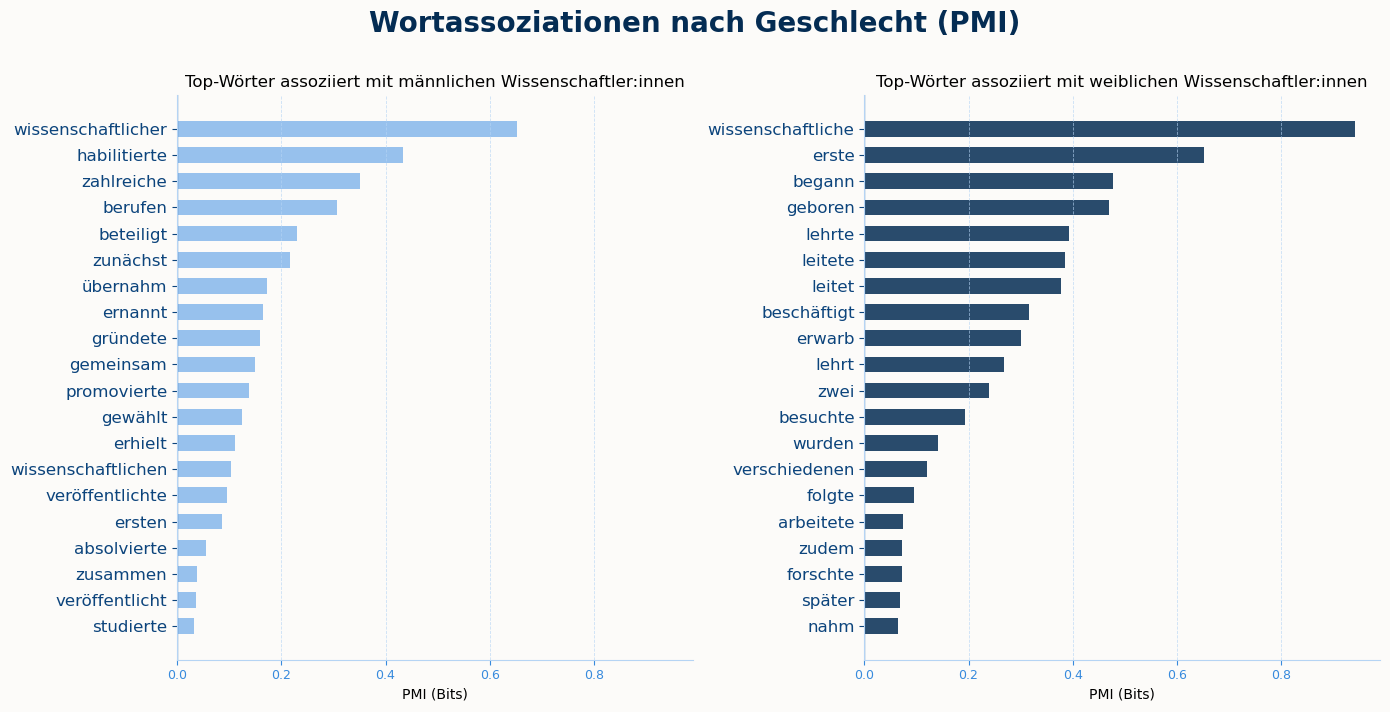

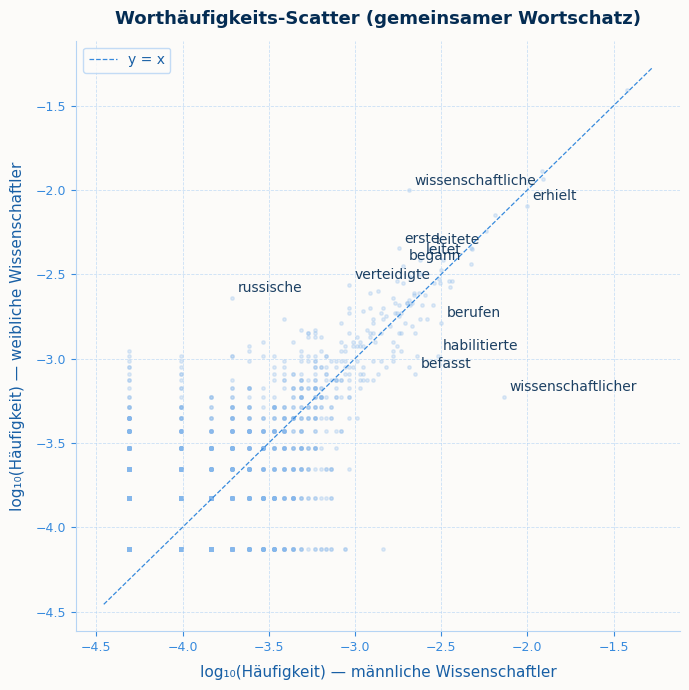

In [25]:
def main():
    print("=" * 60)
    print("Wikipedia Gender Bias Analyser for Scientists")
    print("=" * 60)

    corpora = collect_corpora(df=df)
    print(f"\nCorpus sizes — Männlich: {len(corpora['männlich']):,} tokens, "
          f"Weiblich: {len(corpora['weiblich']):,} tokens")

    freq_m = word_frequencies(corpora["männlich"])
    freq_f = word_frequencies(corpora["weiblich"])

    rho, pval, n_common = rank_correlation(freq_m, freq_f)
    print(f"\nRank correlation (shared vocab, n={n_common:,}):")
    print(f"  ρ = {rho:.3f}  p = {pval:.2e}")

    pmi_data = compute_pmi(corpora, top_n=30)

    print("\nTop 10 männlich assoziierte Wörter (PMI):")
    for w, s in list(pmi_data["männlich"].items())[:10]:
        print(f"  {w:<20} {s:+.3f}")

    print("\nTop 10 weiblich assoziierte Wörter (PMI):")
    for w, s in list(pmi_data["weiblich"].items())[:10]:
        print(f"  {w:<20} {s:+.3f}")

    plot_pmi(pmi_data, top_n=20)
    plot_rank_scatter(freq_m, freq_f)

if __name__ == "__main__":
    main()